In [104]:
#importing necessary functions
#%matplotlib inline
from netCDF4 import Dataset
import numpy as np
from netCDF4 import num2date, date2num
import datetime
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import metpy.calc as mcalc
from metpy.units import units
from metpy.calc import dewpoint_from_relative_humidity as dewpoint_rh
from metpy.calc import specific_humidity_from_dewpoint, wind_components, relative_humidity_from_dewpoint
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import tables
import math
from pydl import uniq
from cartopy.io.shapereader import Reader
from cartopy.feature import ShapelyFeature
from metpy.interpolate import interpolate_to_grid
import matplotlib.gridspec as gridspec
from metpy.plots import SkewT
from metpy.plots import Hodograph

In [105]:
def get_T_wind_err(press_ob):
#Will return T and wind errors given a pressure ob

    #Get error specifications for different variables
    #Pressure array for all of this:
    pres_earr = np.asarray([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 10.0, 20.0, 30.0, 40.0, 50.0, 75.0, 100.0, 150.0, 
                           200.0, 250.0, 300.0, 350.0, 400.0, 450.0, 500.0, 550.0, 600.0, 650.0, 700.0, 
                           750.0, 800.0, 850.0, 900.0, 950.0, 1000.0, 1050.0, 1100.0])
    #Temperature:
    T_earr = np.asarray([1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.25, 1.0, 0.95, 0.9, 0.8, 0.8, 1.0, 1.2, 1.2, 0.9,
                        0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.9, 1.1, 1.2, 1.2, 1.2])

    #Wind:
    wind_earr = np.asarray([2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.4, 2.7, 3.2, 3.0, 2.8,
                           2.6, 2.3, 2.1, 2.0, 1.9, 1.8, 1.6, 1.6, 1.6, 1.5, 1.5, 1.5, 1.4, 1.4, 1.4])

    #Code to grab an error value for a given observation from the above functions
    #press_ob = 960
    for k in range(len(pres_earr)):
        print(pres_earr[k])
        print(press_ob)
        if press_ob <= pres_earr[k]:
            zloc = k-1
            wght = (np.log(pres_earr[k])-np.log(press_ob)) / (np.log(pres_earr[k])-np.log(pres_earr[k-1]))
            break
#     print(wght)
#     print(zloc)
    rawin_wind1 = wght * wind_earr[zloc] + (1.0-wght)*(wind_earr[zloc+1])
    rawin_wind2 = (rawin_wind1 * 10.0) * 0.1
    rawin_T1 = wght * T_earr[zloc] + (1.0-wght)*(T_earr[zloc+1])
    rawin_T2 = (rawin_T1 * 10.0) * 0.1
    
    return rawin_T2, rawin_wind2

In [106]:
T_err1, wind_err1 = get_T_wind_err(1050)
print(T_err1, wind_err1)

0.0
1050
1.0
1050
2.0
1050
3.0
1050
4.0
1050
5.0
1050
10.0
1050
20.0
1050
30.0
1050
40.0
1050
50.0
1050
75.0
1050
100.0
1050
150.0
1050
200.0
1050
250.0
1050
300.0
1050
350.0
1050
400.0
1050
450.0
1050
500.0
1050
550.0
1050
600.0
1050
650.0
1050
700.0
1050
750.0
1050
800.0
1050
850.0
1050
900.0
1050
950.0
1050
1000.0
1050
1050.0
1050
1.2 1.4


In [107]:
def RH_error_from_obs(Td_ferr, T_ferr):
    #Make a function for RH errors
    td_err = 1.5
    t_err = 1

    del_td = 0.1 * units('K')
    del_t = 0.1 * units('K')

    td1 = Td_ferr - del_td
    td2 = np.min(np.asarray([(Td_ferr+del_td).magnitude, (T_ferr+del_t).magnitude]))*units('K')
    t1 = T_ferr - del_t
    t2 = T_ferr + del_t
    rh_deriv_td = ((relative_humidity_from_dewpoint(T_ferr, td2) - relative_humidity_from_dewpoint(T_ferr, td1)) / (td2 - td1)).magnitude
    rh_deriv_t = ((relative_humidity_from_dewpoint(t2, Td_ferr) - relative_humidity_from_dewpoint(t1, Td_ferr)) / (t2 - t1)).magnitude
    print(rh_deriv_td, rh_deriv_t)
    rh_error = np.sqrt((rh_deriv_t*rh_deriv_t*t_err)+(rh_deriv_td*rh_deriv_td*td_err))
    return rh_error

In [108]:
rh_err = RH_error_from_obs(273*units('K'), 275*units('K'))
print(rh_err)

0.062904462286 -0.0618834429938
0.0988181035034


In [109]:
# fig = plt.figure(1, figsize=(12,12))
# plt.plot(T_earr, pres_earr)
# plt.plot(wind_earr, pres_earr)

# plt.ylim(1150, 0)

In [110]:
#You'll need to edit this for every 15-minute assimilation window

dt_start = datetime(2019,6,9,1,0,0)
#Get datetime subsetting nonsense figured out
dt1 = ((dt_start-datetime(1980,1,6)).total_seconds()-450)
dt2 = ((dt_start-datetime(1980,1,6)).total_seconds()+450)

In [111]:
#Read in the soundings from 8 June
#You'll need to add your own list of soundings here
#Unfortunately, they need to be processed one at a time and then combined (if multiple are in the air at once)
#18z Far Field
#s_file = 'C:/Users/matts/Documents/Python Scripts/June8_FF_18z.csv'
#s_file = 'C:/Users/matts/Documents/Python Scripts/June8_FF_20z.csv'
#s_file = 'C:/Users/matts/Documents/Python Scripts/June8_FF_21z.csv'
#s_file = 'C:/Users/matts/Documents/Python Scripts/June8_FF_23z.csv'
s_file = 'C:/Users/matts/Documents/Python Scripts/June9_FF_00z.csv'

FF18z = np.genfromtxt(s_file, delimiter=',')
FF18z_Ti = FF18z[:,0]
#FF18z_Ti[0] = 303.15
#FF18z_Ti[0] = 305.25
#FF18z_Ti[0] = 305.75
#FF18z_Ti[0] = 304.15
FF18z_Ti[0] = 300.15

FF18z_Tdi = FF18z[:,2]
FF18z_Pi = FF18z[:,3]
FF18z_Dir = FF18z[:,4]
#Get wind speed in kt
FF18z_Spd = (FF18z[:,5]*units('m/s'))
FF18z_ui, FF18z_vi = wind_components(FF18z_Spd, FF18z_Dir*units('degree'))
FF18z_zi = FF18z[:,6]
FF18z_lati = FF18z[:,7]
FF18z_loni = FF18z[:,8]

#Convert T and Td to proper units
FF18z_Ti = (FF18z_Ti*units('K')).to('degC')
FF18z_Tdi = (FF18z_Tdi*units('K')).to('degC')

FF18zstr = np.genfromtxt(s_file, delimiter=',', dtype='str')
print(FF18zstr[:,9])
print(FF18zstr[:,9][0][1:5])
print(FF18zstr[:,9][0][6:8])
print(FF18zstr[:,9][0][9:11])
print(FF18zstr[:,9][0][12:14])
print(FF18zstr[:,9][0][15:17])
print(FF18zstr[:,9][0][18:20])

# FF18z = np.genfromtxt('C:/Users/matts/Documents/Python Scripts/June8_FF_18z.csv', delimiter=',')
# FF20z = np.genfromtxt('C:/Users/matts/Documents/Python Scripts/June8_FF_20z.csv', delimiter=',')
# FF21z = np.genfromtxt('C:/Users/matts/Documents/Python Scripts/June8_FF_21z.csv', delimiter=',')
# FF23z = np.genfromtxt('C:/Users/matts/Documents/Python Scripts/June8_FF_23z.csv', delimiter=',')
# FF00z = np.genfromtxt('C:/Users/matts/Documents/Python Scripts/June9_FF_00z.csv', delimiter=',')
# FF03z = np.genfromtxt('C:/Users/matts/Documents/Python Scripts/June9_FF_03z.csv', delimiter=',')



print(FF18z_Ti)

['[2019-06-09T00:54:30.6842928]' '[2019-06-09T00:54:44.8595414]'
 '[2019-06-09T00:54:44.8611491]' ..., '[2019-06-09T01:30:49.0729121]'
 '[2019-06-09T01:30:49.0755808]' '[2019-06-09T01:30:49.0775452]']
2019
06
09
00
54
30
[27.0 27.207700000000045 27.244200000000035 ..., -46.76429999999996 -46.766699999999986 -46.767799999999966] degree_Celsius


In [112]:
#Make datetime arrays
dt_18z = []
for i in range(len(FF18zstr[:,9])):
    yr = int(FF18zstr[:,9][i][1:5])
    mo = int(FF18zstr[:,9][i][6:8])
    dy = int(FF18zstr[:,9][i][9:11])
    hr = int(FF18zstr[:,9][i][12:14])
    mn = int(FF18zstr[:,9][i][15:17])
    sc = int(FF18zstr[:,9][i][18:20])
    dt_tm = datetime(yr,mo,dy,hr,mn,sc)
    dt3 = ((dt_tm-datetime(1980,1,6)).total_seconds())
    dt_18z.append(dt3)

In [113]:
#Subset the data in the sounding by time
dt_18z = np.asarray(dt_18z)
inds_int1 = np.where(np.logical_and(dt_18z < dt2,  dt_18z > dt1))
FF18z_Pa = FF18z_Pi[inds_int1]
FF18z_Ta = FF18z_Ti[inds_int1]
FF18z_Tda = FF18z_Tdi[inds_int1]
FF18z_ua = FF18z_ui[inds_int1]
FF18z_va = FF18z_vi[inds_int1]
FF18z_za = FF18z_zi[inds_int1]
FF18z_lona = FF18z_loni[inds_int1]
FF18z_lata = FF18z_lati[inds_int1]

In [114]:
#Include only points below 2500 ft
hgt_cut = 2500*units('ft')
hgt_cut = hgt_cut.to('m').magnitude

FF18z_P = FF18z_Pa[(FF18z_za-FF18z_zi[0])<hgt_cut]
FF18z_T = FF18z_Ta[(FF18z_za-FF18z_zi[0])<hgt_cut]
FF18z_Td = FF18z_Tda[(FF18z_za-FF18z_zi[0])<hgt_cut]
FF18z_u = FF18z_ua[(FF18z_za-FF18z_zi[0])<hgt_cut]
FF18z_v = FF18z_va[(FF18z_za-FF18z_zi[0])<hgt_cut]
FF18z_z = FF18z_za[(FF18z_za-FF18z_zi[0])<hgt_cut]
FF18z_lon = FF18z_lona[(FF18z_za-FF18z_zi[0])<hgt_cut]
FF18z_lat = FF18z_lata[(FF18z_za-FF18z_zi[0])<hgt_cut]

print(hgt_cut)
print(FF18z_T)

761.9999999999999
[27.0 27.207700000000045 27.244200000000035 27.306399999999996 27.380200000000002 27.434200000000033 27.36710000000005 27.469100000000026 27.556200000000047 27.58970000000005 27.564700000000016 27.509100000000046 27.459600000000023 27.40530000000001 27.37910000000005 27.369100000000003 27.38620000000003 27.31280000000004 27.196300000000008 27.2765 27.345200000000034 27.303200000000004 27.239000000000033 27.200500000000034 27.17670000000004 27.141400000000033 27.06710000000004 27.032100000000014 27.03910000000002 27.005600000000015 26.954700000000003 26.908900000000017 26.85250000000002 26.804900000000032 26.777600000000007 26.7534 26.71900000000005 26.683400000000006 26.656200000000013 26.616100000000017 26.5702 26.51180000000005 26.451900000000023 26.399500000000046 26.353800000000035 26.30110000000002 26.24430000000001 26.192700000000002 26.156200000000013 26.11850000000004 26.059000000000026 25.99970000000002 25.97030000000001 25.93440000000004 25.87990000000002 25

C:\Users\matts\AppData\Local\Temp\ipykernel_3172\3038759187.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  skew.ax.set_xticklabels([-110,-100,-90,-80,-70,-60,-50,-40,-30,-20,-10,0,10,20,30], size = 14)
C:\Users\matts\AppData\Local\Temp\ipykernel_3172\3038759187.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  skew.ax.set_yticklabels([100,200,300,400,500,600,700,800,900,1000],size = 14)


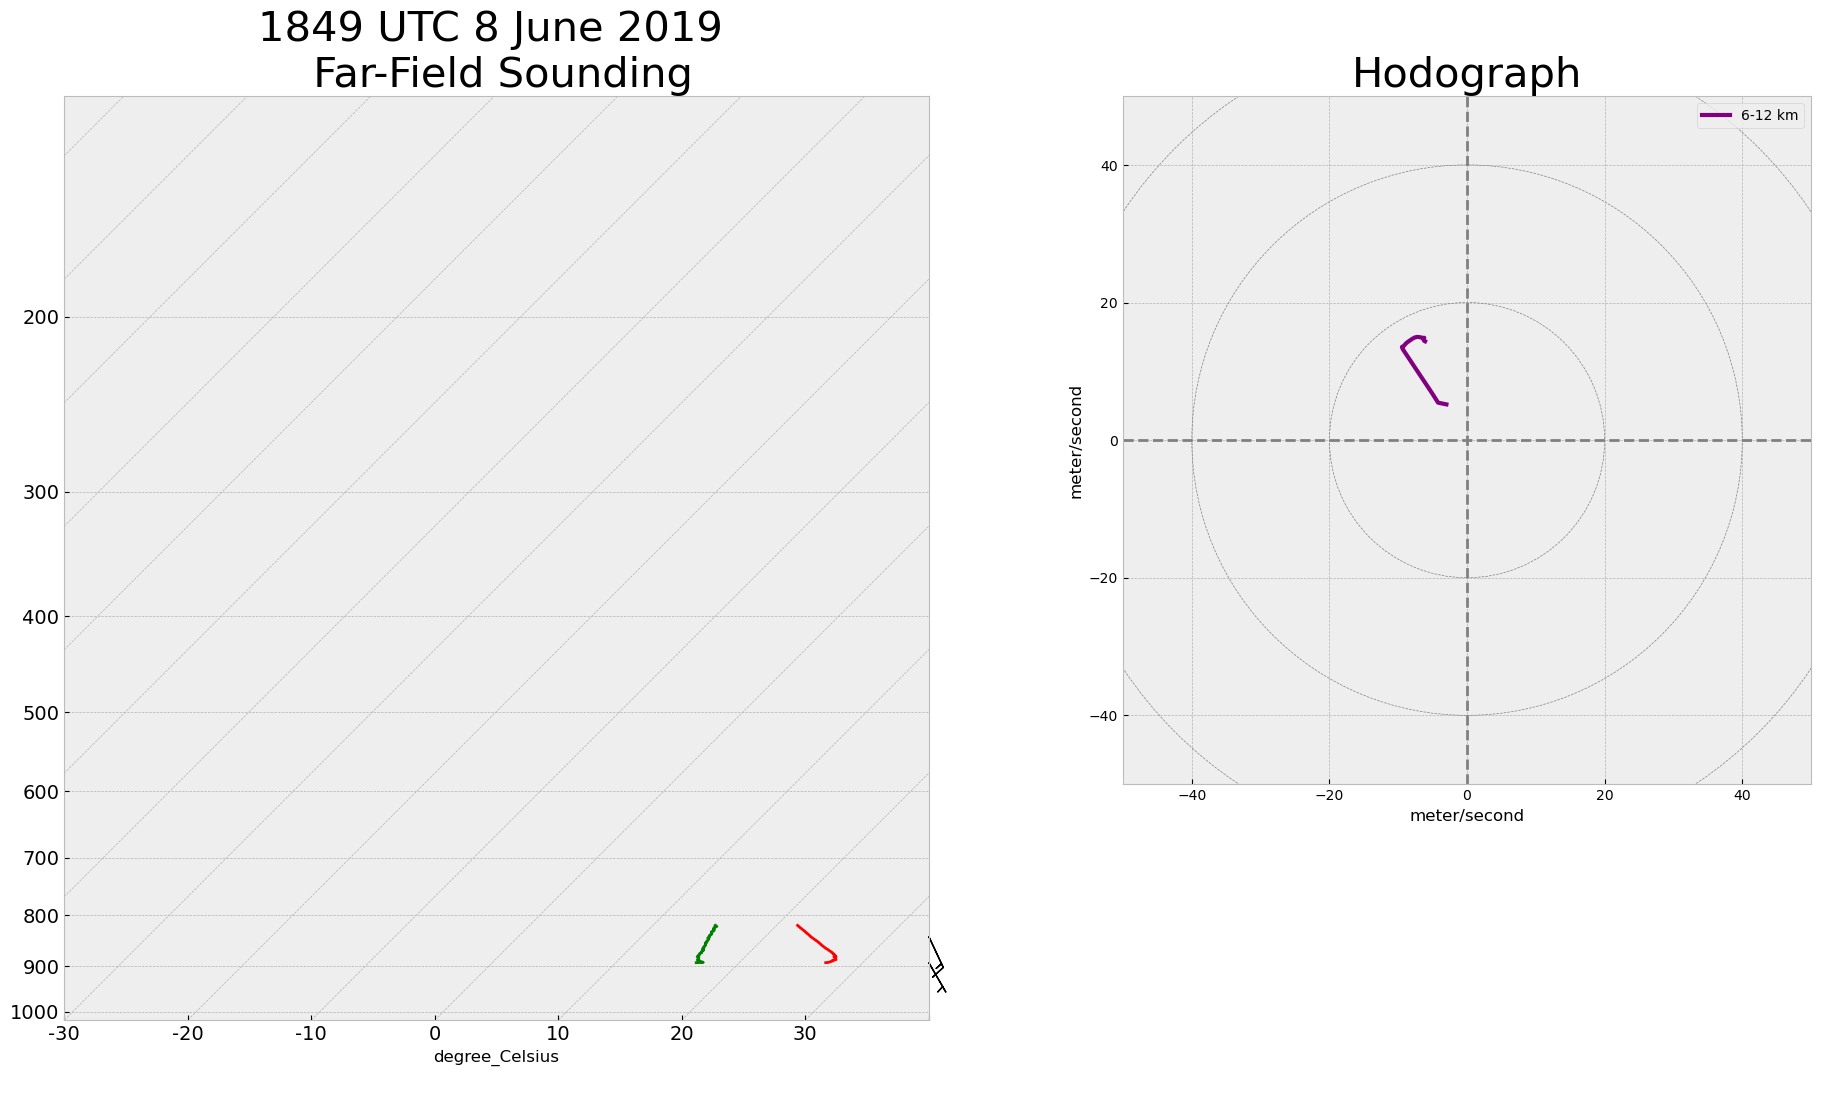

In [115]:
plt.style.use('bmh')
fig = plt.figure(figsize=(24, 12))
gs = gridspec.GridSpec(8, 4)
skew = SkewT(fig, rotation=45, subplot=gs[:, :2])
skew.plot(FF18z_P, FF18z_T, 'r')
skew.plot(FF18z_P, FF18z_Td, 'g')
skew.plot_barbs(FF18z_P[FF18z_P>150][::100], FF18z_u[FF18z_P>150][::100], FF18z_v[FF18z_P>150][::100])
skew.ax.set_ylim(1020, 120)
skew.ax.set_xlim(-30, 40)
skew.ax.set_xticklabels([-110,-100,-90,-80,-70,-60,-50,-40,-30,-20,-10,0,10,20,30], size = 14)
skew.ax.set_yticklabels([100,200,300,400,500,600,700,800,900,1000],size = 14)
plt.title('1849 UTC 8 June 2019 \n Far-Field Sounding', size=30)
ax1 = fig.add_subplot(gs[:6, 2:])
h = Hodograph(ax1,component_range=50.)
h.add_grid(increment=20)
c = h.plot(FF18z_u[FF18z_z-FF18z_z[0]<12000], FF18z_v[FF18z_z-FF18z_z[0]<12000], color='purple', label='6-12 km')
# c = h.plot(FF18z_u[FF18z_z-FF18z_z[0]<6000], FF18z_v[FF18z_z-FF18z_z[0]<6000], color='b', label='3-6 km')
# c = h.plot(FF18z_u[FF18z_z-FF18z_z[0]<3000], FF18z_v[FF18z_z-FF18z_z[0]<3000], color='green', label='1-3 km')
# c = h.plot(FF18z_u[FF18z_z-FF18z_z[0]<1000], FF18z_v[FF18z_z-FF18z_z[0]<1000], color='gold', label='0.5-1 km')
# c = h.plot(FF18z_u[FF18z_z-FF18z_z[0]<500], FF18z_v[FF18z_z-FF18z_z[0]<500], color='red', label='0-0.5 km')

plt.title('Hodograph', size=30)
h.ax.legend()

In [116]:
def profile_super_bin(pres_int, bottom_p, top_p, int4_p, int4_T, int4_Td, int4_U, int4_V, int4_lon, int4_lat, int4_alt):
    #This definition will return obs binned by a pressure interval for later gridding.
    #Inputs:
    #pres_int: pressure interval for the bins
    #bottom_p: bottom (highest) pressure for the profile. 
    #top_P: top (lowest) pressure bin for the profile
    #int4_T: profile temperatures
    #int4_Td: profile dewpoints
    #int4_U, V: profile wind components
    
    mean_T = []
    mean_Td = []
    mean_U = []
    mean_V = []
    mean_lon = []
    mean_lat = []
    mean_alt = []
    mean_p = []

    pres_int = pres_int
    pres_levs = np.arange(bottom_p, top_p, -1*pres_int)
    for levs in pres_levs:
        inds_levs = np.where(np.logical_and(int4_p < levs,  int4_p > levs-10))
        mean_T.append(int4_T[inds_levs])
        mean_Td.append(int4_Td[inds_levs])
        mean_U.append(int4_U[inds_levs])
        mean_V.append(int4_V[inds_levs])
        mean_lon.append(int4_lon[inds_levs])
        mean_lat.append(int4_lat[inds_levs])
        mean_alt.append(int4_alt[inds_levs])
        mean_p.append(int4_p[inds_levs])
        
    return pres_levs, mean_T, mean_Td, mean_U, mean_V, mean_lon, mean_lat, mean_alt, mean_p

In [117]:
#IMPORTANT!!! The bottom pressure level (900 hPa here) may need to change for your soundings depending on where they are.

plevs_18, T_18, Td_18, U_18, V_18, lon_18, lat_18, alt_18, p_18 = profile_super_bin(10, 900, 150, FF18z_P, FF18z_T,
                                                                                   FF18z_Td, FF18z_u, FF18z_v, 
                                                                                   FF18z_lon, FF18z_lat, FF18z_z)

In [118]:
T_18mean = []
Td_18mean = []
U_18mean = []
V_18mean = []
lon_18mean = []
lat_18mean = []
alt_18mean = []
p_18mean = []

for i in range(len(T_18)):
    T_18mn = np.nanmean(T_18[i]).magnitude
    Td_18mn = np.nanmean(Td_18[i]).magnitude
    U_18mn = np.nanmean(U_18[i]).magnitude
    V_18mn = np.nanmean(V_18[i]).magnitude
    lon_18mn = np.nanmean(lon_18[i])
    lat_18mn = np.nanmean(lat_18[i])
    alt_18mn = np.nanmean(alt_18[i])
    p_18mn = np.nanmean(p_18[i])
    T_18mean.append(T_18mn)
    Td_18mean.append(Td_18mn)
    U_18mean.append(U_18mn)
    V_18mean.append(V_18mn)
    lon_18mean.append(lon_18mn)
    lat_18mean.append(lat_18mn)
    alt_18mean.append(alt_18mn)
    p_18mean.append(p_18mn)
    
    #print(T_18mn)
T_18mean = np.asarray(T_18mean)    
Td_18mean = np.asarray(Td_18mean)    
U_18mean = np.asarray(U_18mean)    
V_18mean = np.asarray(V_18mean)    
lon_18mean = np.asarray(lon_18mean)    
lat_18mean = np.asarray(lat_18mean)    
alt_18mean = np.asarray(alt_18mean)    
p_18mean = np.asarray(p_18mean)    
    
T_18mean = T_18mean[~np.isnan(p_18mean)]
Td_18mean = Td_18mean[~np.isnan(p_18mean)]
U_18mean = U_18mean[~np.isnan(p_18mean)]
V_18mean = V_18mean[~np.isnan(p_18mean)]
lon_18mean = lon_18mean[~np.isnan(p_18mean)]
lat_18mean = lat_18mean[~np.isnan(p_18mean)]
alt_18mean = alt_18mean[~np.isnan(p_18mean)]
p_18mean = p_18mean[~np.isnan(p_18mean)]

C:\Users\matts\anaconda3\envs\map2\lib\site-packages\pint\facets\numpy\numpy_func.py:778: RuntimeWarning: Mean of empty slice
  ret = func(*bound_args.args, **bound_args.kwargs)
C:\Users\matts\AppData\Local\Temp\ipykernel_3172\1276596714.py:15: RuntimeWarning: Mean of empty slice
  lon_18mn = np.nanmean(lon_18[i])
C:\Users\matts\AppData\Local\Temp\ipykernel_3172\1276596714.py:16: RuntimeWarning: Mean of empty slice
  lat_18mn = np.nanmean(lat_18[i])
C:\Users\matts\AppData\Local\Temp\ipykernel_3172\1276596714.py:17: RuntimeWarning: Mean of empty slice
  alt_18mn = np.nanmean(alt_18[i])
C:\Users\matts\AppData\Local\Temp\ipykernel_3172\1276596714.py:18: RuntimeWarning: Mean of empty slice
  p_18mn = np.nanmean(p_18[i])


C:\Users\matts\AppData\Local\Temp\ipykernel_3172\2030233383.py:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  skew.ax.set_xticklabels([-110,-100,-90,-80,-70,-60,-50,-40,-30,-20,-10,0,10,20,30], size = 14)
C:\Users\matts\AppData\Local\Temp\ipykernel_3172\2030233383.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  skew.ax.set_yticklabels([100,200,300,400,500,600,700,800,900,1000],size = 14)


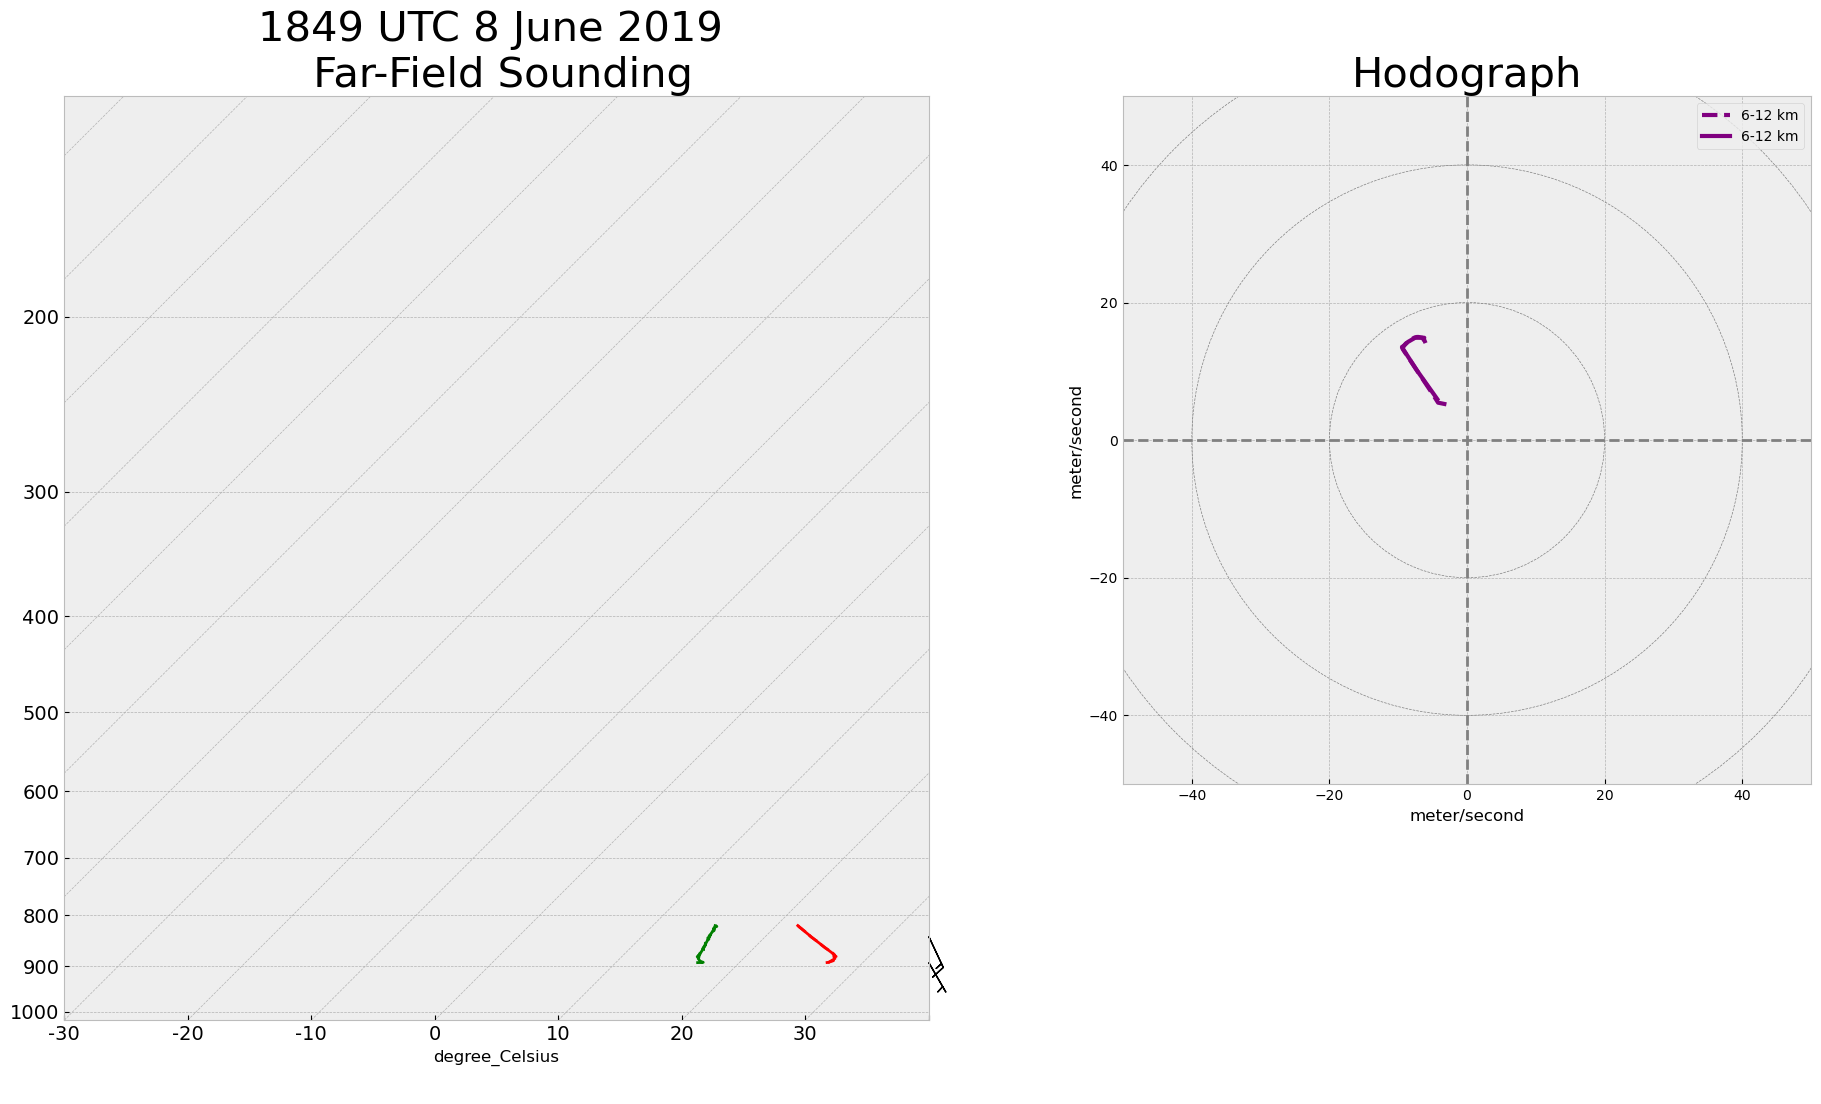

In [119]:
plt.style.use('bmh')
fig = plt.figure(figsize=(24, 12))
gs = gridspec.GridSpec(8, 4)
skew = SkewT(fig, rotation=45, subplot=gs[:, :2])
skew.plot(FF18z_P, FF18z_T, 'r', linestyle = '--')
skew.plot(np.asarray(p_18mean), np.asarray(T_18mean), 'r')
skew.plot(FF18z_P, FF18z_Td, 'g', linestyle = '--')
skew.plot(np.asarray(p_18mean), np.asarray(Td_18mean), 'g')
skew.plot_barbs(FF18z_P[FF18z_P>150][::100], FF18z_u[FF18z_P>150][::100], FF18z_v[FF18z_P>150][::100])
skew.ax.set_ylim(1020, 120)
skew.ax.set_xlim(-30, 40)
skew.ax.set_xticklabels([-110,-100,-90,-80,-70,-60,-50,-40,-30,-20,-10,0,10,20,30], size = 14)
skew.ax.set_yticklabels([100,200,300,400,500,600,700,800,900,1000],size = 14)
plt.title('1849 UTC 8 June 2019 \n Far-Field Sounding', size=30)
ax1 = fig.add_subplot(gs[:6, 2:])
h = Hodograph(ax1,component_range=50.)
h.add_grid(increment=20)
c = h.plot(FF18z_u[FF18z_z-FF18z_z[0]<12000], FF18z_v[FF18z_z-FF18z_z[0]<12000], color='purple', label='6-12 km', linestyle='--')

c = h.plot(np.asarray(U_18mean), np.asarray(V_18mean), color='purple', label='6-12 km')

# c = h.plot(FF18z_u[FF18z_z-FF18z_z[0]<6000], FF18z_v[FF18z_z-FF18z_z[0]<6000], color='b', label='3-6 km')
# c = h.plot(FF18z_u[FF18z_z-FF18z_z[0]<3000], FF18z_v[FF18z_z-FF18z_z[0]<3000], color='green', label='1-3 km')
# c = h.plot(FF18z_u[FF18z_z-FF18z_z[0]<1000], FF18z_v[FF18z_z-FF18z_z[0]<1000], color='gold', label='0.5-1 km')
# c = h.plot(FF18z_u[FF18z_z-FF18z_z[0]<500], FF18z_v[FF18z_z-FF18z_z[0]<500], color='red', label='0-0.5 km')

plt.title('Hodograph', size=30)
h.ax.legend()

In [120]:
print(p_18mean)
print(T_18mean)
print(Td_18mean)

[ 891.68176     884.564525    874.9984619   865.147745    855.06441
  845.154165    834.89167143  825.13636842  819.56943333]
[ 27.2277      27.4137625   26.9054      25.98798     25.04629
  24.108085    23.15973333  22.25771053  21.74013333]
[ 16.83054     16.34091875  16.10314286  15.96654     15.753935
  15.56699     15.36471905  15.22678947  15.04623333]


In [121]:
print(inds_int1)

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 1

In [122]:
print(dt_18z)

[  1.24407687e+09   1.24407688e+09   1.24407688e+09 ...,   1.24407905e+09
   1.24407905e+09   1.24407905e+09]


In [123]:
print(dt1-dt_18z)

[ -120.  -134.  -134. ..., -2299. -2299. -2299.]


In [124]:
#Get errors
sonde_wind_err = []
sonde_T_err = []
sonde_rh_err = []

for i in range(len(p_18mean)):
    T_err1, wind_err1 = get_T_wind_err(p_18mean[i])
    rh_err = RH_error_from_obs((T_18mean[i]+273.15)*units('K'), (Td_18mean[i]+273.15)*units('K'))
    
    sonde_wind_err.append(wind_err1)
    sonde_T_err.append(T_err1)
    sonde_rh_err.append(rh_err)

0.0
891.68176
1.0
891.68176
2.0
891.68176
3.0
891.68176
4.0
891.68176
5.0
891.68176
10.0
891.68176
20.0
891.68176
30.0
891.68176
40.0
891.68176
50.0
891.68176
75.0
891.68176
100.0
891.68176
150.0
891.68176
200.0
891.68176
250.0
891.68176
300.0
891.68176
350.0
891.68176
400.0
891.68176
450.0
891.68176
500.0
891.68176
550.0
891.68176
600.0
891.68176
650.0
891.68176
700.0
891.68176
750.0
891.68176
800.0
891.68176
850.0
891.68176
900.0
891.68176
0.0852305273321 -0.119770872815
0.0
884.564525
1.0
884.564525
2.0
884.564525
3.0
884.564525
4.0
884.564525
5.0
884.564525
10.0
884.564525
20.0
884.564525
30.0
884.564525
40.0
884.564525
50.0
884.564525
75.0
884.564525
100.0
884.564525
150.0
884.564525
200.0
884.564525
250.0
884.564525
300.0
884.564525
350.0
884.564525
400.0
884.564525
450.0
884.564525
500.0
884.564525
550.0
884.564525
600.0
884.564525
650.0
884.564525
700.0
884.564525
750.0
884.564525
800.0
884.564525
850.0
884.564525
900.0
884.564525
0.0873426261424 -0.12538688409
0.0
874.99846190

In [125]:
#Get RH from T and Td:
RH_18mean = relative_humidity_from_dewpoint(T_18mean*units('degC'), Td_18mean*units('degC')).magnitude

In [126]:
print(RH_18mean)

[ 0.53007595  0.50824415  0.5157662   0.53974486  0.5631153   0.58856051
  0.61516037  0.64405744  0.65705445]


In [127]:
#Convert lons and lats to radians
lon_18meanf = np.radians(lon_18mean)
lat_18meanf = np.radians(lat_18mean)

lon_18meanf = np.where(lon_18meanf > 0.0, lon_18meanf, lon_18meanf+(2.0*np.pi))

In [128]:
# Write out the data to an obs_seq file
#Set up some times
dt_time3  = dt_start - datetime(1601,1,1,0,0,0)
dt_seconds3 = dt_time3.seconds
dt_days3 = dt_time3.days

oerror_U = sonde_wind_err
oerror_V = sonde_wind_err
oerror_Td = sonde_rh_err
oerror_T = sonde_T_err

print(dt_time3.seconds)
print(dt_time3.days)

3600
152830


In [129]:
time_bracket = dt_start

#Set up some code to write out an obs_seq file
#Code adapted from PyOpaws's obs_seq writing code
#Set obs types
akind1 = 12
akind2 = 103
akind3 = 8
akind4 = 9

#nobs=2
ob_ind = 1
data = T_18mean
data = np.asarray(data)
data = data + 273.15
data2 = RH_18mean
data2 = np.asarray(data2)
data3 = U_18mean
data3 = np.asarray(data3)
data4 = V_18mean
data4 = np.asarray(data4)

kind1arr = np.full(len(data), akind1)
kind2arr = np.full(len(data2), akind2)
kind3arr = np.full(len(data3), akind3)
kind4arr = np.full(len(data4), akind4)
oerrarr1 = oerror_T
oerrarr2 = oerror_Td
oerrarr3 = oerror_U
oerrarr4 = oerror_V

#Concatenate arrays and make static arrays
data_all = np.concatenate([data, data2, data3, data4])
lons_all = np.concatenate([lon_18meanf, lon_18meanf, lon_18meanf, lon_18meanf])
lats_all = np.concatenate([lat_18meanf, lat_18meanf, lat_18meanf, lat_18meanf])
alts_all = np.concatenate([alt_18mean, alt_18mean, alt_18mean, alt_18mean])
kinds_all = np.concatenate([kind1arr, kind2arr, kind3arr, kind4arr])
errs_all = np.concatenate([oerrarr1, oerrarr2, oerrarr3, oerrarr4])

nobs = len(data_all)
truth = 1.0

DARTname1 = 'RADIOSONDE_TEMPERATURE'
DARTname2 = 'RADIOSONDE_RELATIVE_HUMIDITY'
DARTname3 = 'RADIOSONDE_U_WIND_COMPONENT'
DARTname4 = 'RADIOSONDE_V_WIND_COMPONENT'

filename = 'obs_TORUS_SONDEPBL2022'+str(time_bracket.hour)+str(time_bracket.minute)
fi = open(filename, "w")

fi.write(" obs_sequence\n")
fi.write("obs_kind_definitions\n")

if len(data) > 0:

    fi.write("    %d \n" %(4))
    fi.write("    %d          %s   \n" %(akind1, DARTname1))
    fi.write("    %d          %s   \n" %(akind2, DARTname2))
    fi.write("    %d          %s   \n" %(akind3, DARTname3))
    fi.write("    %d          %s   \n" %(akind4, DARTname4))

else:
    
    fi.write("    %d \n" %(2))
    fi.write("    %d          %s   \n" %(akind2, DARTname2))
    fi.write("    %d          %s   \n" %(akind3, DARTname3))
    
fi.write("  num_copies:            %d  num_qc:            %d\n" % (1, 1))
fi.write(" num_obs:       %d  max_num_obs:       %d\n" % (nobs, nobs) )

fi.write("MADIS observation\n")
fi.write("Data QC\n")

fi.write("  first:            %d  last:       %d\n" % (1, nobs) )

for q in range(nobs):

    fi.write(" OBS            %d\n" % (q+1) )
    fi.write("   %20.14f\n" % data_all[q]  )
    fi.write("   %20.14f\n" % truth )

    if q+1 == 1: 
      fi.write(" %d %d %d\n" % (-1, q+2, -1) ) # First obs.
    elif q+1 == nobs:
      fi.write(" %d %d %d\n" % (q, -1, -1) ) # Last obs.
    else:
      fi.write(" %d %d %d\n" % (q, q+2, -1) ) 

    fi.write("obdef\n")
    fi.write("loc3d\n")

    fi.write("    %20.14f          %20.14f          %20.14f     %d\n" % 
                      (lons_all[q], lats_all[q], alts_all[q], 3))
    fi.write("kind\n")
    
    fi.write("     %d     \n" % kinds_all[q] )
    
    fi.write("    %d          %d     \n" % (dt_seconds3, dt_days3) )
    
    fi.write("    %20.14f  \n" % errs_all[q]**2 )